In [9]:
#To Get the Retail data and to store in the data dir as CSV

from pathlib import Path
import pandas as pd
import requests

FRED_KEY = "12e263bebb317344d2fec79c573734b8"
url = "https://api.stlouisfed.org/fred/series/observations"
params = {
"series_id": "RSXFS",
"api_key": FRED_KEY,
"file_type": "json",
"observation_start": "2010-01-01",
}
r = requests.get(url, params=params, timeout=30)
#r.raise_for_status()
df = pd.DataFrame(r.json()["observations"])[["date", "value"]]
df["date"] = pd.to_datetime(df["date"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna().sort_values("date").reset_index(drop=True)
Path("data").mkdir(exist_ok=True)
df.to_csv("data/retail_sales_fred.csv", index=False)

In [12]:
import yfinance as yf
wmt = yf.Ticker("WMT")
quarterly = wmt.quarterly_financials # rows are line items, columns are quarter-end dates ↪
revenue = quarterly.loc["Total Revenue"]

In [15]:
#To get the Walmart Revenue data scraped from web and stored in Data Dir as CSV

from pathlib import Path
import pandas as pd
import requests
USER_AGENT = "Thamotharan thamotharan.ofi@gmail.com" # SEC requires this header
frames = []
for concept in ("Revenues","RevenueFromContractWithCustomerExcludingAssessedTax"):
    url = ("https://data.sec.gov/api/xbrl/companyconcept/"f"CIK0000104169/us-gaap/{concept}.json")
    r = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=30)
    if r.status_code == 404:
        continue
    r.raise_for_status()
    units = r.json().get("units", {}).get("USD", [])
    if units:
        frames.append(pd.DataFrame(units))

raw = pd.concat(frames, ignore_index=True)
raw["start"] = pd.to_datetime(raw["start"])
raw["end"] = pd.to_datetime(raw["end"])
raw["filed"] = pd.to_datetime(raw["filed"])
raw["days"] = (raw["end"]- raw["start"]).dt.days

# quarterly facts ~ 89-94 days; fiscal-year facts ~ 360-371 days
raw = raw[raw["days"].between(80, 100) | raw["days"].between(355,375)].copy()

raw["kind"] = raw["days"].apply(lambda d: "Q" if d <= 100 else "FY")
# dedupe amendments: keep the latest filing per (start, end, kind)
raw = raw.sort_values("filed").drop_duplicates(["start", "end", "kind"],keep="last")
q_facts = (raw[raw["kind"] == "Q"][["end", "val"]].rename(columns={"end": "date", "val": "value"}))
# derive Q4 = FY- (Q1 + Q2 + Q3) for each fiscal year
q4_rows = []
for _, fy in raw[raw["kind"] == "FY"].iterrows():
    in_fy = q_facts[(q_facts["date"] > fy["start"]) & (q_facts["date"] <fy["end"])]
    if len(in_fy) == 3:
        q4_rows.append({"date": fy["end"],"value": float(fy["val"]) - float(in_fy["value"].sum())})

revenue = pd.concat([q_facts, pd.DataFrame(q4_rows)], ignore_index=True)
revenue["value"] = revenue["value"].astype(float)
revenue = (revenue.drop_duplicates("date")
            .sort_values("date")
            .query("date >= '2010-01-01'")
            .reset_index(drop=True))
Path("data").mkdir(exist_ok=True)
revenue.to_csv("data/walmart_revenue.csv", index=False)

In [2]:
#Import Necessary Libraries for EDA

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Read Data from CSV

retail = pd.read_csv("data/retail_sales_fred.csv")
revenue = pd.read_csv("data/walmart_revenue.csv")

In [4]:
# Summary of Retail
retail.head(10)

,date,value
0,2010-01-01,302325.0
1,2010-02-01,302310.0
2,2010-03-01,309525.0
3,2010-04-01,312143.0
4,2010-05-01,309158.0
5,2010-06-01,308588.0
6,2010-07-01,309543.0
7,2010-08-01,310761.0
8,2010-09-01,313785.0
9,2010-10-01,317699.0


In [6]:
# Summary of Revenue
revenue.head()

,date,value
0,2010-01-31,1.135940e+11
1,2010-04-30,9.981100e+10
2,2010-07-31,1.037260e+11
3,2010-10-31,1.019520e+11
4,2011-01-31,1.163600e+11


In [8]:
# List of column Names

print(retail.columns)
print(revenue.columns)

Index(['date', 'value'], dtype='object')
Index(['date', 'value'], dtype='object')


In [9]:
# Rename the Column from values to Retail and Revenue in both the Data Frames

retail = retail.rename(columns={"value":"retail"})
revenue = revenue.rename(columns={"value":"revenue"})


In [10]:
print(retail.columns)
print(revenue.columns)

Index(['date', 'retail'], dtype='object')
Index(['date', 'revenue'], dtype='object')


In [11]:
# To check the Data Frame with the Data types and Missing Values

print(retail.info())
print(revenue.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    195 non-null    object 
 1   retail  195 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     65 non-null     object 
 1   revenue  65 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.1+ KB
None


In [12]:
# To Change the Date column from Object to the Date Field

retail["date"] = pd.to_datetime(retail["date"])
revenue["date"] = pd.to_datetime(revenue["date"])

In [13]:
print(retail.info())
print(revenue.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    195 non-null    datetime64[ns]
 1   retail  195 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.2 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     65 non-null     datetime64[ns]
 1   revenue  65 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.1 KB
None


In [14]:
# To check any null values

print(retail.isna().sum())
print(revenue.isna().sum())

date      0
retail    0
dtype: int64
date       0
revenue    0
dtype: int64


In [15]:
# Ordering or Sorting the Dataframe based on Date

retail = retail.sort_values("date")
revenue = revenue.sort_values("date")

In [16]:
# Set Index Values

retail = retail.reset_index(drop=True)
revenue = revenue.reset_index(drop=True)

In [17]:
# To Explore the Date Range of Retail

print("Retail Data Range")
print(retail["date"].min())
print(retail["date"].max())

Retail Data Range
2010-01-01 00:00:00
2026-03-01 00:00:00


In [18]:
# To Explore the Date Range of Revenue

print("Revenue Data Range")
print(revenue["date"].min())
print(revenue["date"].max())

Revenue Data Range
2010-01-31 00:00:00
2026-01-31 00:00:00


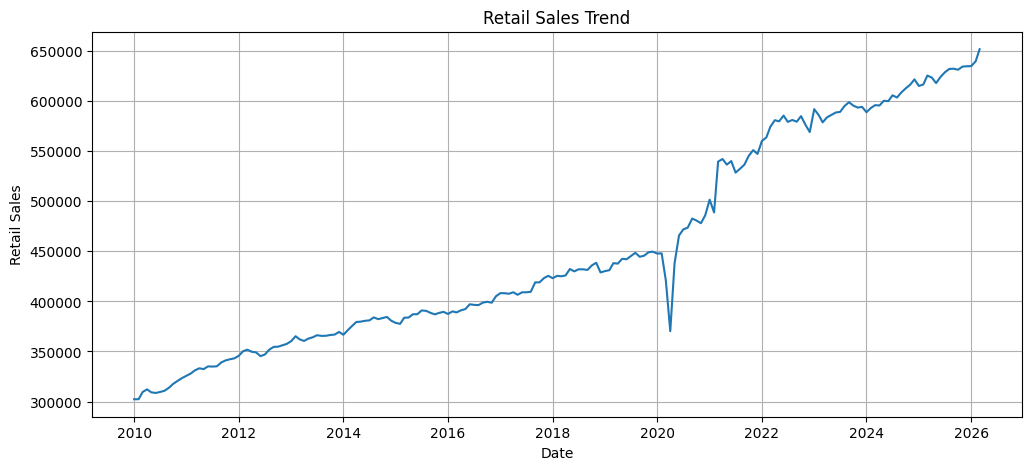

In [19]:
# Basic Visualization for the Retail sales trend

plt.figure(figsize=(12,5))

plt.plot(retail["date"],retail["retail"])

plt.title("Retail Sales Trend")
plt.xlabel("Date")
plt.ylabel("Retail Sales")

plt.grid(True)
plt.show()

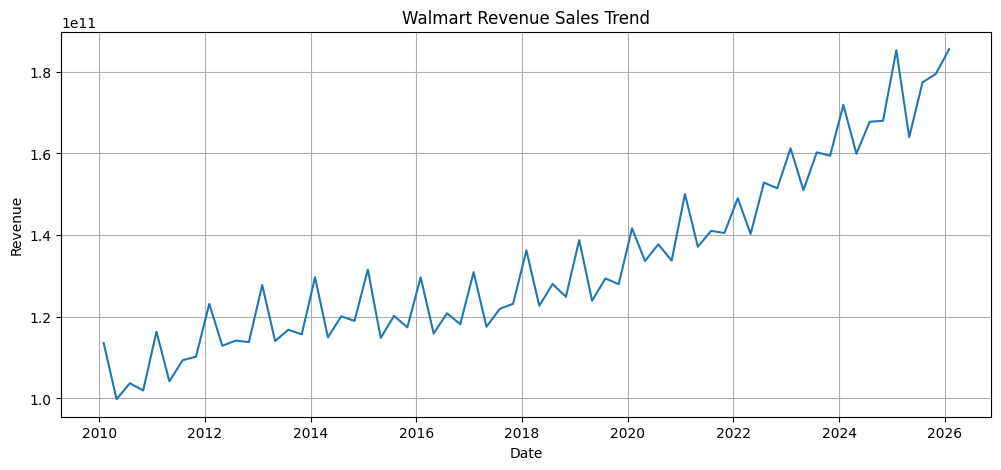

In [21]:
# Basic Visualization for the Walmart Revenue Sales Trend

plt.figure(figsize=(12,5))

plt.plot(revenue["date"],revenue["revenue"])

plt.title("Walmart Revenue Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)
plt.show()

In [22]:
# Create year and Quarter in Retail

retail["year"] = retail["date"].dt.year
retail["quarter"] = retail["date"].dt.quarter

In [23]:
# Create Year and Quarter in Revenue

revenue["year"] = revenue["date"].dt.year
revenue["quarter"] = revenue["date"].dt.quarter

In [24]:
# Merging Retail and Revenue as Single Table

df = pd.merge(retail,revenue,on=["year", "quarter"],how="inner")

In [25]:
print(df.shape)

display(df.head())

(195, 6)


,date_x,retail,year,quarter,date_y,revenue
0,2010-01-01,302325.0,2010,1,2010-01-31,1.135940e+11
1,2010-02-01,302310.0,2010,1,2010-01-31,1.135940e+11
2,2010-03-01,309525.0,2010,1,2010-01-31,1.135940e+11
3,2010-04-01,312143.0,2010,2,2010-04-30,9.981100e+10
4,2010-05-01,309158.0,2010,2,2010-04-30,9.981100e+10


In [26]:
# Limit one date field in the DataFrame

df = df[["date_x","year","quarter","retail","revenue"]]

df.columns = ["date","year","quarter","retail","revenue"]

In [27]:
df.head()

,date,year,quarter,retail,revenue
0,2010-01-01,2010,1,302325.0,1.135940e+11
1,2010-02-01,2010,1,302310.0,1.135940e+11
2,2010-03-01,2010,1,309525.0,1.135940e+11
3,2010-04-01,2010,2,312143.0,9.981100e+10
4,2010-05-01,2010,2,309158.0,9.981100e+10


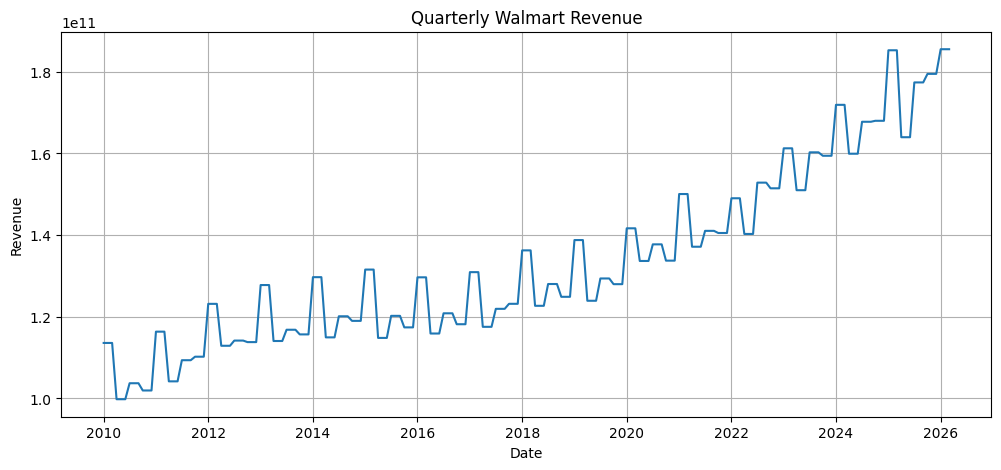

In [28]:
# Quarterly Walmart Revenue trend

plt.figure(figsize=(12,5))

plt.plot(df["date"],df["revenue"])

plt.title("Quarterly Walmart Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [29]:
# Revenue Comparision Year-Over-Year

df["revenue_yoy"] = (df["revenue"].pct_change(4))

In [30]:
# Retail Comparision Year-Over-Year

df["retail_yoy"] = (df["retail"].pct_change(4))

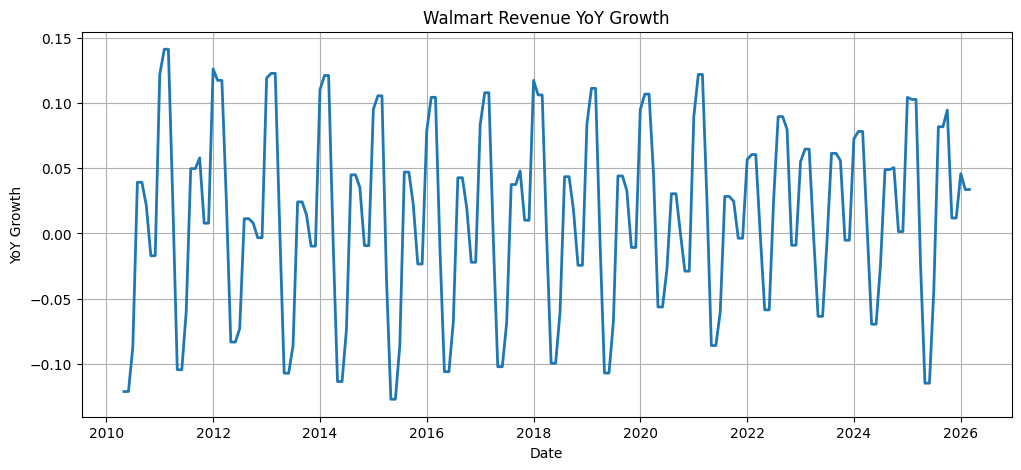

In [31]:
# Year-over-Year Growth Revenue Stats

plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["revenue_yoy"],
    linewidth=2
)

plt.title("Walmart Revenue YoY Growth")
plt.xlabel("Date")
plt.ylabel("YoY Growth")

plt.grid(True)

plt.show()

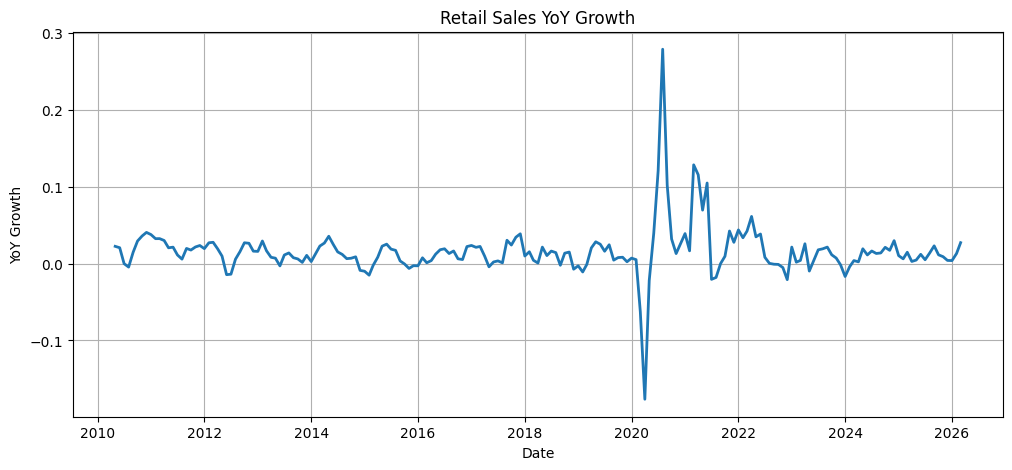

In [32]:
# Year-over-Year Retail Stats

plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["retail_yoy"],
    linewidth=2
)

plt.title("Retail Sales YoY Growth")
plt.xlabel("Date")
plt.ylabel("YoY Growth")

plt.grid(True)

plt.show()

In [33]:
# Previous quarter retail growth

df["retail_yoy_lag1"] = (df["retail_yoy"].shift(1))

In [34]:
# Two-quarter lag

df["retail_yoy_lag2"] = (df["retail_yoy"].shift(2))

In [35]:
# Three-quarter lag

df["retail_yoy_lag3"] = (df["retail_yoy"].shift(3))

In [36]:
df.head(12)

,date,year,quarter,retail,revenue,revenue_yoy,retail_yoy,retail_yoy_lag1,retail_yoy_lag2,retail_yoy_lag3
0,2010-01-01,2010,1,302325.0,1.135940e+11,NaN,NaN,NaN,NaN,NaN
1,2010-02-01,2010,1,302310.0,1.135940e+11,NaN,NaN,NaN,NaN,NaN
2,2010-03-01,2010,1,309525.0,1.135940e+11,NaN,NaN,NaN,NaN,NaN
3,2010-04-01,2010,2,312143.0,9.981100e+10,NaN,NaN,NaN,NaN,NaN
4,2010-05-01,2010,2,309158.0,9.981100e+10,-0.121336,0.022602,NaN,NaN,NaN
5,2010-06-01,2010,2,308588.0,9.981100e+10,-0.121336,0.020767,0.022602,NaN,NaN
6,2010-07-01,2010,3,309543.0,1.037260e+11,-0.086871,0.000058,0.020767,0.022602,NaN
7,2010-08-01,2010,3,310761.0,1.037260e+11,0.039224,-0.004427,0.000058,0.020767,0.022602
8,2010-09-01,2010,3,313785.0,1.037260e+11,0.039224,0.014966,-0.004427,0.000058,0.020767
9,2010-10-01,2010,4,317699.0,1.019520e+11,0.021451,0.029525,0.014966,-0.004427,0.000058


In [37]:
# Rolling average of retail growth

df["retail_rolling_mean"] = (df["retail_yoy"].rolling(2).mean())

In [38]:
model_df = df.dropna().reset_index(drop=True)

In [39]:
# Seasonal naive baseline
model_df["baseline_pred"] = (model_df["revenue_yoy"].shift(4))

In [40]:
baseline_df = model_df.dropna().reset_index(drop=True)

In [41]:
# Baseline Model data

baseline_df.head(12)

,date,year,quarter,retail,revenue,revenue_yoy,retail_yoy,retail_yoy_lag1,retail_yoy_lag2,retail_yoy_lag3,retail_rolling_mean,baseline_pred
0,2010-12-01,2010,4,323421.0,1.019520e+11,-0.017103,0.040739,0.036027,0.029525,0.014966,0.038383,0.039224
1,2011-01-01,2011,1,325674.0,1.163600e+11,0.121802,0.037889,0.040739,0.036027,0.029525,0.039314,0.039224
2,2011-02-01,2011,1,328049.0,1.163600e+11,0.141321,0.032578,0.037889,0.040739,0.036027,0.035234,0.021451
3,2011-03-01,2011,1,331161.0,1.163600e+11,0.141321,0.032635,0.032578,0.037889,0.040739,0.032607,-0.017103
4,2011-04-01,2011,2,333189.0,1.041890e+11,0.021942,0.030202,0.032635,0.032578,0.037889,0.031419,-0.017103
5,2011-05-01,2011,2,332409.0,1.041890e+11,-0.104598,0.020680,0.030202,0.032635,0.032578,0.025441,0.121802
6,2011-06-01,2011,2,335108.0,1.041890e+11,-0.104598,0.021518,0.020680,0.030202,0.032635,0.021099,0.141321
7,2011-07-01,2011,3,334922.0,1.093660e+11,-0.060107,0.011357,0.021518,0.020680,0.030202,0.016438,0.141321
8,2011-08-01,2011,3,335163.0,1.093660e+11,0.049689,0.005925,0.011357,0.021518,0.020680,0.008641,0.021942
9,2011-09-01,2011,3,339011.0,1.093660e+11,0.049689,0.019861,0.005925,0.011357,0.021518,0.012893,-0.104598


In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [43]:
# Actual values
y_true = baseline_df["revenue_yoy"]

# Baseline predictions
y_pred = baseline_df["baseline_pred"]

In [44]:
#MAE Evaluation

mae_baseline = mean_absolute_error(y_true,y_pred)

In [45]:
# RMSE Evaluation

rmse_baseline = np.sqrt(mean_squared_error(y_true,y_pred))

In [46]:
# MAPE Evaluation

mape_baseline = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [47]:
print("Baseline Model Performance")

print(f"MAE  : {mae_baseline:.4f}")
print(f"RMSE : {rmse_baseline:.4f}")
print(f"MAPE : {mape_baseline:.2f}%")

Baseline Model Performance
MAE  : 0.1010
RMSE : 0.1203
MAPE : 341.94%


In [48]:
# Training Data Split

features = [
    "retail_yoy_lag1",
    "retail_yoy_lag2",
    "retail_yoy_lag3",
    "retail_rolling_mean"
]

In [49]:
# Target Value

target = "revenue_yoy"

In [50]:
predictions = []
actuals = []
dates = []

In [51]:
START_TRAIN_SIZE = 12

In [52]:
from sklearn.linear_model import LinearRegression

In [62]:
for i in range(START_TRAIN_SIZE, len(model_df)):

    train = model_df.iloc[:i]
    test = model_df.iloc[i:i+1]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]

    predictions.append(pred)
    actuals.append(y_test.values[0])
    dates.append(test["date"].values[0])

In [63]:
results = pd.DataFrame({"date": dates,"actual": actuals,"predicted": predictions})

In [64]:
display(results.head())

,date,actual,predicted
0,2026-03-01,0.033639,0.014659
1,2011-08-01,0.049689,-0.038447
2,2011-09-01,0.049689,0.049622
3,2011-10-01,0.057943,-0.058523
4,2011-11-01,0.007864,0.008806


In [65]:
# MAE Evaluation

mae_model = mean_absolute_error(results["actual"],results["predicted"])

In [66]:
# RSME Evaluation

rmse_model = np.sqrt(mean_squared_error(results["actual"],results["predicted"]))

In [67]:
# MAPE Evaluation

mape_model = np.mean(np.abs((results["actual"] - results["predicted"]) / results["actual"])) * 100

In [68]:
print("Regression Model Performance")

print(f"MAE  : {mae_model:.4f}")
print(f"RMSE : {rmse_model:.4f}")
print(f"MAPE : {mape_model:.2f}%")

Regression Model Performance
MAE  : 0.0605
RMSE : 0.0735
MAPE : 236.17%


In [69]:
# Model Comparision On Evaluation

comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "Retail Regression"
    ],
    "MAPE": [
        mape_baseline,
        mape_model
    ],
    "RMSE": [
        rmse_baseline,
        rmse_model
    ]
})

comparison

,Model,MAPE,RMSE
0,Seasonal Naive,341.944608,0.120264
1,Retail Regression,236.174274,0.073530


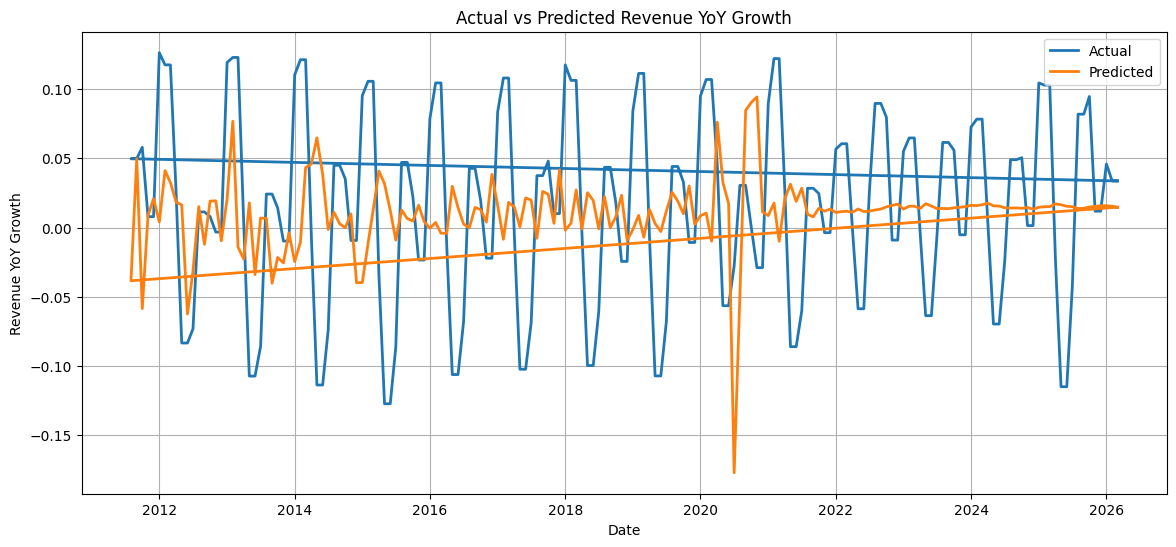

In [70]:
# Actual Vs Predicted GRowth

plt.figure(figsize=(14,6))

plt.plot(results["date"],results["actual"],label="Actual",linewidth=2)

plt.plot(
    results["date"],
    results["predicted"],
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Revenue YoY Growth")

plt.xlabel("Date")
plt.ylabel("Revenue YoY Growth")

plt.legend()

plt.grid(True)

plt.show()